# Campaign Management

A `Campaign` is the top-level container for a flight planning effort. It defines
a geographic domain, fetches reference data (airspace boundaries), and manages a
library of flight lines organized into groups.

This notebook demonstrates:

1. Creating a campaign with a geographic domain
2. Fetching airspace data from OpenAIP (or using synthetic data)
3. Adding flight lines and organizing them into groups
4. Checking for airspace conflicts
5. Saving and loading campaigns as folders
6. Inspecting the saved folder structure

See also: [airspace_check.ipynb](airspace_check.ipynb) for lower-level airspace API details.

In [1]:
import os
import json
import tempfile

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Polygon
from dotenv import load_dotenv

from hyplan.campaign import Campaign
from hyplan.airspace import Airspace, check_airspace_conflicts, parse_airspace_items
from hyplan.flight_line import FlightLine
from hyplan.units import ureg

# Load API keys from .env file in the project root
load_dotenv(os.path.join(os.path.dirname(os.getcwd()), ".env"))
load_dotenv()  # also check current directory

True

## 1. Create a Campaign

A campaign starts with a geographic domain — the area you plan to fly in.
Define it with a bounding box or a Shapely Polygon.

In [2]:
# Option 1: Bounding box (min_lon, min_lat, max_lon, max_lat)
# Santa Barbara / Vandenberg area
campaign = Campaign(
    name="Santa Barbara Coastal 2026",
    bounds=(-121.0, 34.3, -119.5, 35.0),
    country="US",
)

print(campaign.summary())

Campaign: Santa Barbara Coastal 2026
  Domain: (-121.0, 34.3, -119.5, 35.0)
  Country: US
  Airspaces: not fetched
  Flight lines: 0
  Groups: 0


In [3]:
# Option 2: Custom polygon (for irregular study areas)
custom_poly = Polygon([
    (-120.8, 34.4), (-120.8, 34.9),
    (-119.8, 34.9), (-119.6, 34.5),
    (-119.8, 34.4), (-120.8, 34.4),
])
campaign_poly = Campaign(
    name="Custom Domain",
    polygon=custom_poly,
)

# We'll use the bounding-box campaign for the rest of this notebook
print(f"Bounding box campaign: {campaign.bounds}")
print(f"Polygon campaign:      {campaign_poly.bounds}")

Bounding box campaign: (-121.0, 34.3, -119.5, 35.0)
Polygon campaign:      (-120.8, 34.4, -119.6, 34.9)


## 2. Fetch Airspace Data

`fetch_airspaces()` pulls airspace boundaries from the OpenAIP API and caches
them locally. If you don't have an API key, we'll use synthetic airspace data
to demonstrate the workflow.

To use real data, set `OPENAIP_API_KEY` in your environment.

In [4]:
api_key = os.environ.get("OPENAIP_API_KEY", "")

if api_key:
    # Real data from OpenAIP
    campaign.fetch_airspaces(api_key=api_key)
    print(f"Fetched {len(campaign.airspaces)} airspaces from OpenAIP")
else:
    # Synthetic airspace data for demonstration
    from shapely.geometry import box as shapely_box

    synthetic_airspaces = [
        Airspace(
            name="R-2516 (Vandenberg)",
            airspace_class="RESTRICTED",
            airspace_type=1,
            floor_ft=0,
            ceiling_ft=3280,
            geometry=shapely_box(-120.73, 34.64, -120.45, 35.0),
            country="US",
        ),
        Airspace(
            name="DZ PCA023 (Vandenberg)",
            airspace_class="DANGER",
            airspace_type=2,
            floor_ft=0,
            ceiling_ft=17999,
            geometry=shapely_box(-120.54, 34.59, -120.38, 34.73),
            country="US",
        ),
        Airspace(
            name="Lompoc Class D",
            airspace_class="D",
            airspace_type=4,
            floor_ft=0,
            ceiling_ft=2900,
            geometry=shapely_box(-120.69, 34.65, -120.48, 34.82),
            country="US",
        ),
    ]

    campaign._airspaces = synthetic_airspaces
    campaign._raw_airspace_items = []
    print(f"Using {len(synthetic_airspaces)} synthetic airspace zones")
    print("Set OPENAIP_API_KEY in .env to use real data")

print(campaign.summary())

Using 3 synthetic airspace zones
Set OPENAIP_API_KEY in .env to use real data
Campaign: Santa Barbara Coastal 2026
  Domain: (-121.0, 34.3, -119.5, 35.0)
  Country: US
  Airspaces: 3
  Flight lines: 0
  Groups: 0


## 3. Add Flight Lines

Flight lines are organized into **groups**. A group represents lines that were
generated together — a flight box, a racetrack pattern, or manually placed lines.
Each group tracks its member lines and optionally the parameters used to generate them.

In [5]:
# Group 1: Coastal transects along the Santa Barbara Channel
coastal_lines = []
for i, offset_lat in enumerate([-0.02, -0.01, 0.0, 0.01, 0.02]):
    fl = FlightLine.start_length_azimuth(
        lat1=34.45 + offset_lat, lon1=-120.2 + offset_lat * 0.3,
        length=ureg.Quantity(60, "km"), az=290,
        altitude_msl=ureg.Quantity(20000, "foot"),
        site_name=f"Coastal {i+1}",
    )
    coastal_lines.append(fl)

g1 = campaign.add_flight_lines(
    coastal_lines,
    group_name="Coastal transects",
    group_type="flight_box",
    generation_params={
        "method": "manual parallel lines",
        "nlines": 5,
        "altitude_ft": 20000,
    },
)
print(f"Added group: {g1} ({len(coastal_lines)} lines)")

# Group 2: An inland survey line in the Santa Ynez Valley
inland_line = FlightLine.center_length_azimuth(
    lat=34.7, lon=-119.9,
    length=ureg.Quantity(40, "km"), az=270,
    altitude_msl=ureg.Quantity(4000, "foot"),
    site_name="Santa Ynez Valley",
)

g2 = campaign.add_flight_lines(
    [inland_line],
    group_name="Inland survey line",
    group_type="single_line",
)
print(f"Added group: {g2} (1 line)")

# Group 3: A line that passes through Vandenberg restricted airspace
vandenberg_line = FlightLine.start_length_azimuth(
    lat1=34.65, lon1=-120.8,
    length=ureg.Quantity(50, "km"), az=60,
    altitude_msl=ureg.Quantity(2500, "foot"),
    site_name="Vandenberg pass",
)

g3 = campaign.add_flight_lines(
    [vandenberg_line],
    group_name="Vandenberg pass",
    group_type="single_line",
)
print(f"Added group: {g3} (1 line)")

print(f"\nTotal: {len(campaign.flight_lines)} flight lines in {len(campaign.groups)} groups")

Added group: group_001 (5 lines)
Added group: group_002 (1 line)
Added group: group_003 (1 line)

Total: 7 flight lines in 3 groups


## 4. Visualize the Campaign

Plot the domain boundary, airspace zones, and all flight lines.

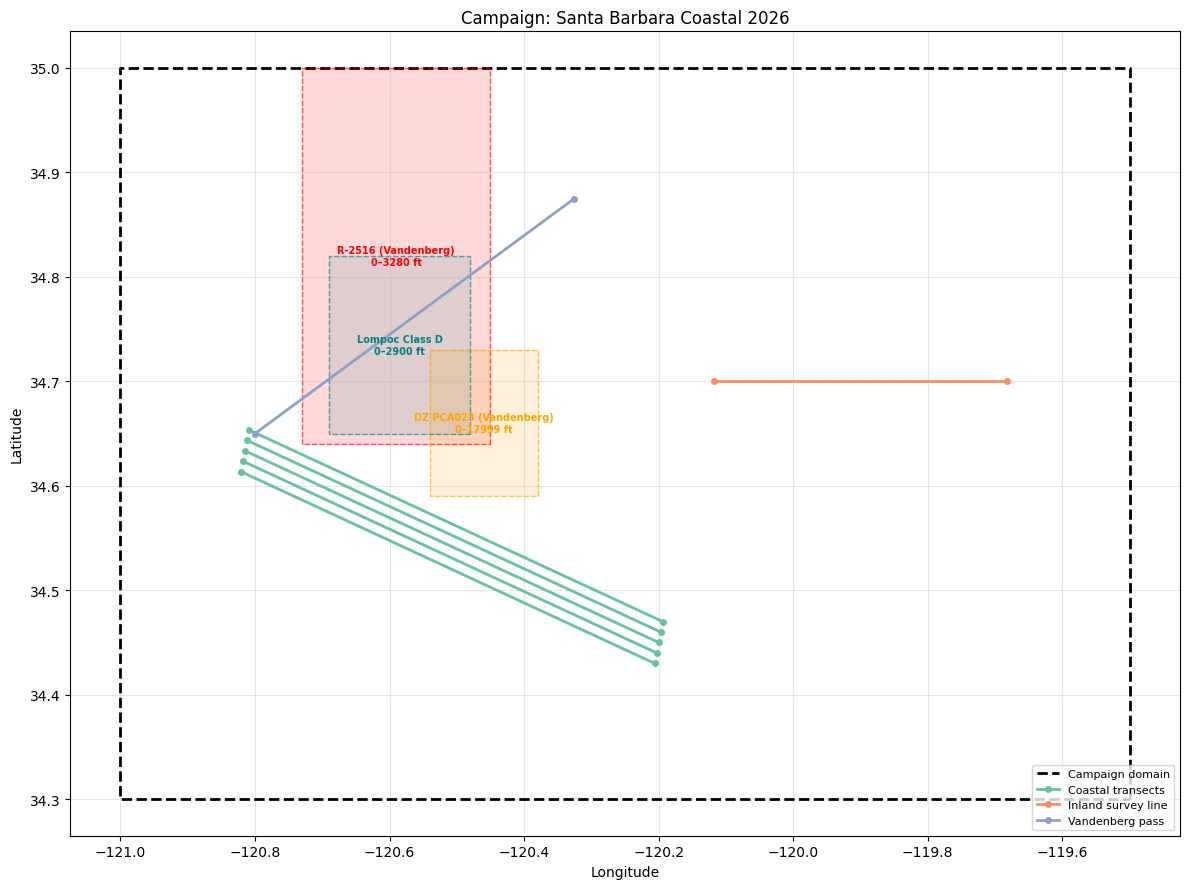

In [6]:
fig, ax = plt.subplots(figsize=(12, 9))

# Domain boundary
dx, dy = campaign.polygon.exterior.xy
ax.plot(dx, dy, "k--", linewidth=2, label="Campaign domain")

# Airspace zones
as_colors = {
    "RESTRICTED": ("red", 0.15),
    "DANGER": ("orange", 0.15),
    "B": ("blue", 0.12),
    "C": ("purple", 0.12),
    "D": ("teal", 0.12),
    "OTHER": ("gray", 0.10),
}
for a in campaign.airspaces:
    color, alpha = as_colors.get(a.airspace_class, ("gray", 0.1))
    x, y = a.geometry.exterior.xy
    ax.fill(x, y, alpha=alpha, color=color)
    ax.plot(x, y, "--", color=color, linewidth=1, alpha=0.6)
    cx, cy = a.geometry.centroid.coords[0]
    ax.text(cx, cy, f"{a.name}\n{a.floor_ft:.0f}–{a.ceiling_ft:.0f} ft",
            ha="center", va="center", fontsize=7, color=color, weight="bold")

# Flight lines colored by group
group_colors = plt.cm.Set2.colors
for gi, group in enumerate(campaign.groups):
    color = group_colors[gi % len(group_colors)]
    for li, line_id in enumerate(group["line_ids"]):
        fl = campaign._flight_lines[line_id]
        lons, lats = zip(*fl.geometry.coords)
        label = group["name"] if li == 0 else None
        ax.plot(lons, lats, "-o", color=color, linewidth=2, markersize=4, label=label)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Campaign: {campaign.name}")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Check Airspace Conflicts

`check_conflicts()` tests all campaign flight lines against the fetched airspace
data. It checks both horizontal (polygon intersection) and vertical (altitude
overlap) criteria.

In [7]:
# Check all campaign flight lines against airspaces
conflicts = campaign.check_conflicts()

if conflicts:
    print(f"Found {len(conflicts)} conflict(s):\n")
    for c in conflicts:
        fl = campaign.flight_lines[c.flight_line_index]
        alt = fl.altitude_msl.to("foot").magnitude
        print(f"  {fl.site_name} (alt {alt:,.0f} ft)")
        print(f"    ↔ {c.airspace.name} ({c.airspace.airspace_class}, "
              f"{c.airspace.floor_ft:.0f}–{c.airspace.ceiling_ft:.0f} ft)")
        print()
else:
    print("No airspace conflicts found.")

Found 2 conflict(s):

  Vandenberg pass (alt 2,500 ft)
    ↔ Lompoc Class D (D, 0–2900 ft)

  Vandenberg pass (alt 2,500 ft)
    ↔ R-2516 (Vandenberg) (RESTRICTED, 0–3280 ft)



## 6. Managing Groups

You can remove a group (and its flight lines) if they conflict or are no longer needed.

In [8]:
# List current groups
print("Current groups:")
for g in campaign.groups:
    print(f"  {g['id']}: {g['name']} ({g['type']}, {len(g['line_ids'])} lines)")

# Remove the conflicting high-altitude pass
campaign.remove_group(g3)
print(f"\nRemoved '{g3}'. Remaining: {len(campaign.flight_lines)} lines, {len(campaign.groups)} groups")

# Verify no more conflicts
conflicts = campaign.check_conflicts()
print(f"Conflicts after removal: {len(conflicts)}")

Current groups:
  group_001: Coastal transects (flight_box, 5 lines)
  group_002: Inland survey line (single_line, 1 lines)
  group_003: Vandenberg pass (single_line, 1 lines)

Removed 'group_003'. Remaining: 6 lines, 2 groups
Conflicts after removal: 0


## 7. Save the Campaign

`save()` writes everything to a plain folder. Each file uses its natural format
and can be opened independently in QGIS, Python, or a text editor.

In [9]:
# Save to a temporary folder for demonstration
save_dir = os.path.join(tempfile.gettempdir(), "sb_campaign_2026")
campaign.save(save_dir)

# Show the folder structure
print(f"Saved to: {save_dir}\n")
for root, dirs, files in os.walk(save_dir):
    level = root.replace(save_dir, "").count(os.sep)
    indent = "  " * level
    basename = os.path.basename(root) or os.path.basename(save_dir)
    print(f"{indent}{basename}/")
    for f in sorted(files):
        filepath = os.path.join(root, f)
        size = os.path.getsize(filepath)
        print(f"{indent}  {f}  ({size:,} bytes)")

Saved to: /var/folders/tk/dltx8gp544z3_ddzcb8c1_7r0000gn/T/sb_campaign_2026

sb_campaign_2026/
  airspaces.json  (76 bytes)
  campaign.json  (142 bytes)
  domain.geojson  (517 bytes)
  flight_lines/
    all_lines.geojson  (3,159 bytes)
    groups.json  (522 bytes)


In [10]:
# Peek at campaign.json
with open(os.path.join(save_dir, "campaign.json")) as f:
    print("campaign.json:")
    print(json.dumps(json.load(f), indent=2))

campaign.json:
{
  "version": 1,
  "name": "Santa Barbara Coastal 2026",
  "country": "US",
  "fetched_at": null,
  "line_counter": 7,
  "group_counter": 3
}


## 8. Load a Saved Campaign

`Campaign.load()` reconstructs a campaign from a saved folder. No API calls
are made — airspace data is re-parsed from the stored raw items.

In [11]:
# Load the campaign we just saved
loaded = Campaign.load(save_dir)

print(loaded.summary())
print(f"\nRound-trip check:")
print(f"  Name matches:        {loaded.name == campaign.name}")
print(f"  Bounds match:        {loaded.bounds == campaign.bounds}")
print(f"  Country matches:     {loaded.country == campaign.country}")
print(f"  Flight lines:        {len(loaded.flight_lines)} (original: {len(campaign.flight_lines)})")
print(f"  Groups:              {len(loaded.groups)} (original: {len(campaign.groups)})")

# Verify flight line geometry survived the round-trip
for orig, loaded_fl in zip(campaign.flight_lines, loaded.flight_lines):
    assert orig.site_name == loaded_fl.site_name, f"Name mismatch: {orig.site_name} vs {loaded_fl.site_name}"
    assert abs(orig.lat1 - loaded_fl.lat1) < 1e-4, "Latitude mismatch"
    assert abs(orig.lon1 - loaded_fl.lon1) < 1e-4, "Longitude mismatch"
print("\nAll flight line geometries match.")

Campaign: Santa Barbara Coastal 2026
  Domain: (-121.0, 34.3, -119.5, 35.0)
  Country: US
  Airspaces: 0
  Flight lines: 6
  Groups: 2
    group_001: Coastal transects (flight_box, 5 lines)
    group_002: Inland survey line (single_line, 1 lines)

Round-trip check:
  Name matches:        True
  Bounds match:        True
  Country matches:     True
  Flight lines:        6 (original: 6)
  Groups:              2 (original: 2)

All flight line geometries match.


In [12]:
# Peek at the GeoJSON flight lines — these open directly in QGIS
with open(os.path.join(save_dir, "flight_lines", "all_lines.geojson")) as f:
    fc = json.load(f)

print(f"all_lines.geojson: {len(fc['features'])} features\n")
for feat in fc["features"]:
    props = feat["properties"]
    coords = feat["geometry"]["coordinates"]
    print(f"  {feat['id']}: {props.get('site_name', '?')}"
          f"  alt={props.get('altitude_msl', '?')} m"
          f"  ({len(coords)} vertices)")

all_lines.geojson: 6 features

  line_001: Coastal 1  alt=6095.999999999999 m  (2 vertices)
  line_002: Coastal 2  alt=6095.999999999999 m  (2 vertices)
  line_003: Coastal 3  alt=6095.999999999999 m  (2 vertices)
  line_004: Coastal 4  alt=6095.999999999999 m  (2 vertices)
  line_005: Coastal 5  alt=6095.999999999999 m  (2 vertices)
  line_006: Santa Ynez Valley  alt=1219.1999999999998 m  (2 vertices)
